In [1]:
import torch

In [2]:
from torch.distributions.multivariate_normal import MultivariateNormal
from torch.distributions.normal import Normal
from torch.distributions.independent import Independent

loc = torch.zeros(3)
scale = torch.ones(3)
mvn = MultivariateNormal(loc, scale_tril=torch.diag(scale))
print ([mvn.batch_shape, mvn.event_shape])
normal = Normal(loc, scale)
print ([normal.batch_shape, normal.event_shape])
diagn = Independent(normal, 1)
print ([diagn.batch_shape, diagn.event_shape])

[torch.Size([]), torch.Size([3])]
[torch.Size([3]), torch.Size([])]
[torch.Size([]), torch.Size([3])]


In [8]:
torch.diag(scale)

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])

## Visualizing Torch Distributions
Let's sample from each distribution and visualize the results using matplotlib.

In [3]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
%matplotlib inline

In [9]:
# Sample from each distribution
n_samples = 1000
samples_mvn = mvn.sample((n_samples,))
samples_normal = normal.sample((n_samples,))
samples_diagn = diagn.sample((n_samples,))

print (samples_mvn.shape)
print (samples_normal.shape)
print (samples_diagn.shape)

torch.Size([1000, 3])
torch.Size([1000, 3])
torch.Size([1000, 3])


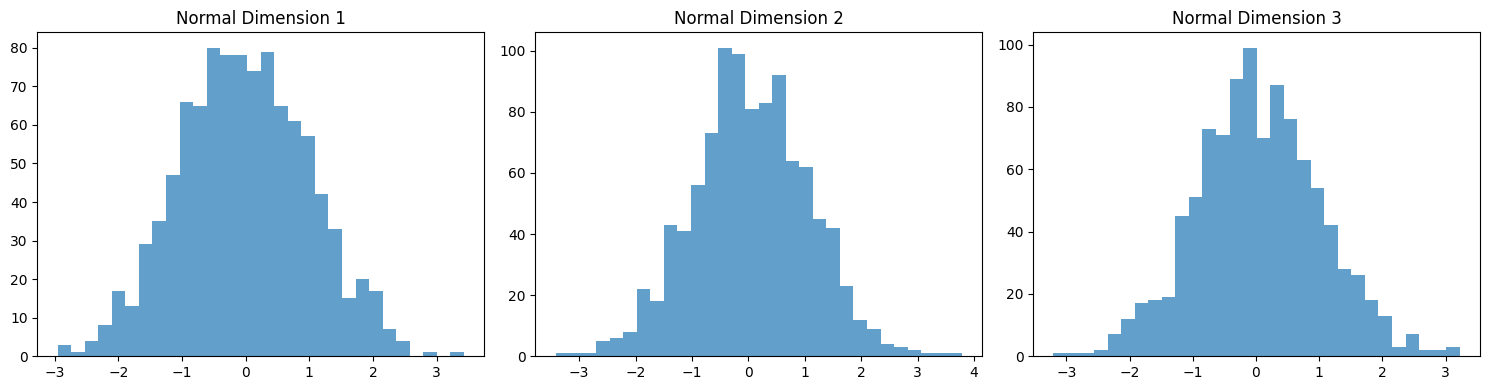

In [10]:
# Plot histograms for each dimension of Normal distribution
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
for i in range(3):
    axs[i].hist(samples_normal[:, i].numpy(), bins=30, alpha=0.7)
    axs[i].set_title(f'Normal Dimension {i+1}')
plt.tight_layout()
plt.show()

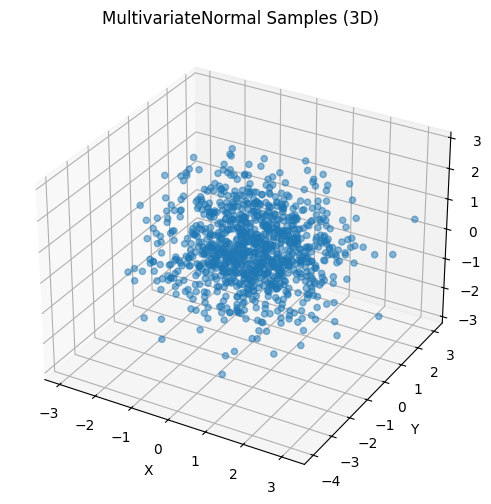

In [11]:
# 3D scatter plot for MultivariateNormal samples
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(samples_mvn[:, 0].numpy(), samples_mvn[:, 1].numpy(), samples_mvn[:, 2].numpy(), alpha=0.5)
ax.set_title('MultivariateNormal Samples (3D)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

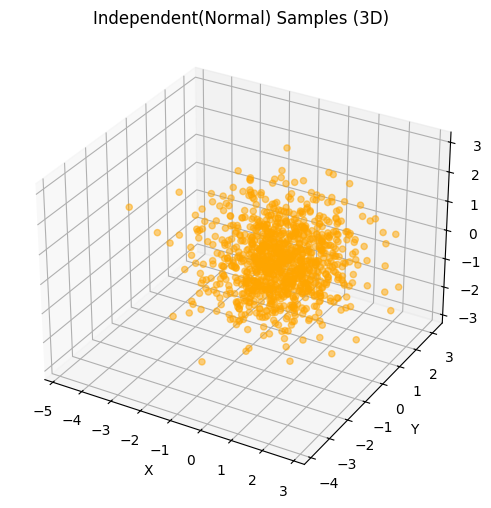

In [13]:
# 3D scatter plot for Independent(Normal) samples
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(samples_diagn[:, 0].numpy(), samples_diagn[:, 1].numpy(), samples_diagn[:, 2].numpy(), alpha=0.5, color='orange')
ax.set_title('Independent(Normal) Samples (3D)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

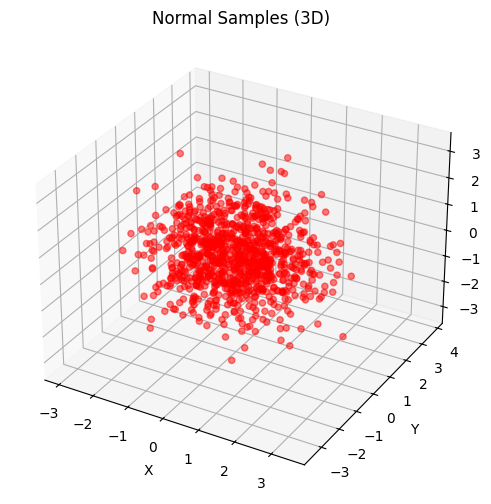

In [14]:
# This is my exploration - not generated by Copilot
# 3D scatter plot for Normal samples 
fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(samples_normal[:, 0].numpy(), samples_normal[:, 1].numpy(), samples_normal[:, 2].numpy(), alpha=0.5, color='red')
ax.set_title('Normal Samples (3D)')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

# 2D Torch Distributions: Build, Sample, and Visualize
This section demonstrates how to create, sample, and plot 2D distributions using PyTorch and matplotlib.

In [15]:
import torch
from torch.distributions.multivariate_normal import MultivariateNormal
from torch.distributions.normal import Normal
from torch.distributions.independent import Independent

In [16]:
# Build 2D distributions
loc = torch.zeros(2)
scale = torch.ones(2)
mvn_2d = MultivariateNormal(loc, scale_tril=torch.diag(scale))
normal_2d = Normal(loc, scale)
diagn_2d = Independent(normal_2d, 1)

In [17]:
# Sample from each 2D distribution
n_samples = 1000
samples_mvn_2d = mvn_2d.sample((n_samples,))
samples_normal_2d = normal_2d.sample((n_samples,))
samples_diagn_2d = diagn_2d.sample((n_samples,))

In [18]:
import matplotlib.pyplot as plt
%matplotlib inline

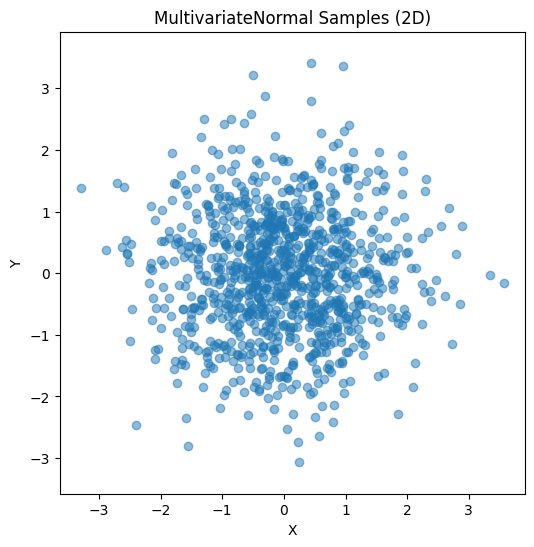

In [19]:
# Plot 2D samples from MultivariateNormal
plt.figure(figsize=(6, 6))
plt.scatter(samples_mvn_2d[:, 0].numpy(), samples_mvn_2d[:, 1].numpy(), alpha=0.5)
plt.title('MultivariateNormal Samples (2D)')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.show()

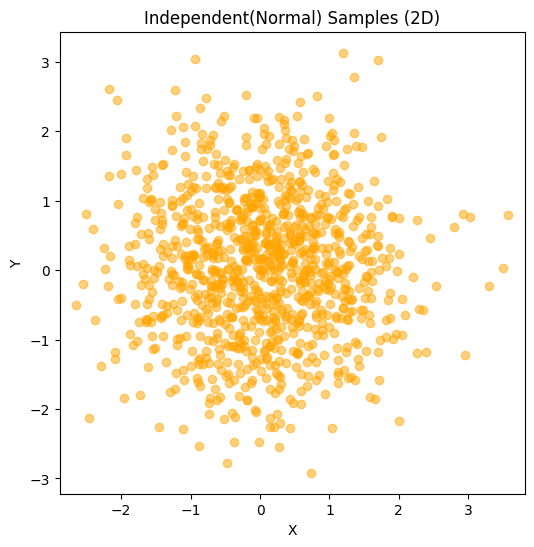

In [20]:
# Plot 2D samples from Independent(Normal)
plt.figure(figsize=(6, 6))
plt.scatter(samples_diagn_2d[:, 0].numpy(), samples_diagn_2d[:, 1].numpy(), alpha=0.5, color='orange')
plt.title('Independent(Normal) Samples (2D)')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.show()

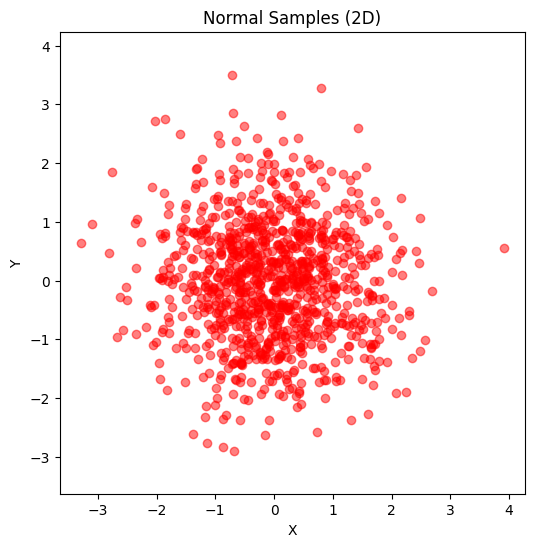

In [21]:
# Again, this cell is my extension to copilot's code
# Plot 2D samples from Normal
plt.figure(figsize=(6, 6))
plt.scatter(samples_normal_2d[:, 0].numpy(), samples_normal_2d[:, 1].numpy(), alpha=0.5, color='red')
plt.title('Normal Samples (2D)')
plt.xlabel('X')
plt.ylabel('Y')
plt.axis('equal')
plt.show()